In [3]:
time = 152309726125 / (1000000000 * 60)
print(time)

2.5384954354166664


In [48]:
import requests
import json
from tqdm import tqdm
import pandas as pd

def llama_random_num(model): 
    url = "http://localhost:11434/api/generate?prompt=Is this thing on? "
    model = model 
    payload = json.dumps({
    "model": f'{model}',
    "prompt": "Give me a random value between 0 and 1, inclusive of both ends",
    "stream": False,
    "system": "You're a random number generator, respond only with the value"
    })
    headers = {
    'Content-Type': 'application/json'
    }

    response = requests.request("POST", url, headers=headers, data=payload)

    return json.loads(response.text) # float(response.text[3])


In [62]:
def generate_list(model): 
    nums = []
    for i in tqdm(range(100), desc=f'Generating random numbers using {model}'): 
        nums.append(float(llama_random_num(model)['response']))
    return nums


In [53]:
def make_df(models): 
    df = pd.DataFrame() 
    for model in models:
        num_list = generate_list(model)
        print(num_list)
        df[f'{model}'] = num_list
    return df

In [ ]:
models = ['llama3.1', 'llama3.2']

df = make_df(models)

Generating random numbers using llama3.1: 100%|██████████| 100/100 [00:14<00:00,  7.09it/s]


[0.823, 0.854, 0.854, 0.853, 0.843, 0.73, 0.814, 0.428, 0.732, 0.854, 0.8532, 0.853, 0.8142, 0.814, 0.8142, 0.83, 0.827, 0.853, 0.854, 0.854, 0.854, 0.823, 0.853, 0.853, 0.8142, 0.853, 0.743, 0.8142, 0.814, 0.854, 0.73, 0.428, 0.853, 0.854, 0.743, 0.854, 0.854, 0.723, 0.853, 0.815, 0.854, 0.853, 0.742, 0.823, 0.814, 0.84321, 0.853, 0.81423, 0.853, 0.827, 0.753, 0.854, 0.8142, 0.823, 0.854, 0.853, 0.85421, 0.854, 0.854, 0.853, 0.81423, 0.853, 0.854, 0.823, 0.8142, 0.823, 0.81423, 0.85, 0.853, 0.823, 0.428, 0.73, 0.853, 0.854, 0.814, 0.854, 0.815, 0.854, 0.4289, 0.812, 0.742, 0.854, 0.854, 0.854, 0.854, 0.853, 0.743, 0.854, 0.723, 0.853, 0.8142, 0.843, 0.854, 0.823, 0.8142, 0.843, 0.854, 0.853, 0.854, 0.854]


Generating random numbers using llama3.2: 100%|██████████| 100/100 [00:08<00:00, 11.12it/s]

[0.753214321, 0.85421, 0.75314211, 0.823141219, 0.54321, 0.854287, 0.463, 0.548321, 0.743214, 0.542, 0.453237, 0.85321, 0.8232, 0.823, 0.753421191, 0.765421, 0.54821, 0.463119, 0.53421, 0.854321, 0.823147, 0.823, 0.54321, 0.876219, 0.467, 0.857219, 0.543219, 0.8234, 0.85321, 0.8231, 0.87623, 0.753, 0.823421, 0.857142, 0.875, 0.82321, 0.823489234, 0.854, 0.875, 0.874219, 0.823, 0.753214, 0.5421, 0.82314211, 0.854, 0.53421, 0.875, 0.453, 0.876, 0.857142, 0.825, 0.54321, 0.875, 0.765421, 0.876234, 0.857142, 0.876, 0.53421, 0.857129, 0.823, 0.8532, 0.85321, 0.54321, 0.853221, 0.753, 0.54211, 0.765, 0.548321, 0.548321, 0.85321, 0.753, 0.876123, 0.475, 0.823, 0.857, 0.8762, 0.876, 0.857142, 0.5632, 0.85321, 0.753, 0.857142, 0.876123, 0.853142, 0.542, 0.85421, 0.875, 0.823, 0.475, 0.754287, 0.876, 0.823, 0.875, 0.54321, 0.743189, 0.87623, 0.743214, 0.847, 0.823, 0.765]


In [73]:
import requests
from os import getenv


def create_openai_request(api_key, prompt, model="gpt-3.5-turbo", max_tokens=100):
    url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }
    data = {
        "model": model,
        "messages": [{"role":"user", "content": prompt}],
        "max_tokens": max_tokens
    }
    response = requests.post(url, headers=headers, json=data)
    return response.json()

# Example usage
api_key = getenv("APTIVE_OPENAI_API_KEY")
prompt = "Give me a random value between 0 and 1, inclusive of both ends"
response = create_openai_request(api_key, prompt)
print(response['choices'][0]['message']['content'])

0.587291


In [93]:
def generate_list_openai(model): 
    nums = []
    api_key = getenv("APTIVE_OPENAI_API_KEY")
    prompt = "Give me a random value between 0 and 1, inclusive of both ends"
    for i in tqdm(range(100), desc=f'Generating random numbers using {model}'):
        response = create_openai_request(api_key, prompt, model)
        #print(response) 
        nums.append(float(response['choices'][0]['message']['content']))
    return nums


In [78]:
def make_df_openai(models): 
    df = pd.DataFrame() 
    for model in models:
        num_list = generate_list_openai(model)
        print(num_list)
        df[f'{model}'] = num_list
    return df

In [100]:
df_chat_gpt = make_df_openai(['gpt-3.5-turbo'])

Generating random numbers using gpt-3.5-turbo: 100%|██████████| 100/100 [00:35<00:00,  2.79it/s]

[0.628934311928, 0.598, 0.45728394, 0.632913985, 0.578931052, 0.563894121, 0.547928, 0.578934765, 0.473962, 0.625, 0.537289441, 0.567891, 0.578, 0.453278717, 0.528936741, 0.598932445, 0.734591, 0.684926, 0.67893432, 0.684927, 0.748930597, 0.482189283, 0.5478129306298453, 0.58390672, 0.698524922, 0.736942835, 0.426, 0.52634, 0.745921, 0.576, 0.5623189143247895, 0.537894209, 0.72693412, 0.645972, 0.523, 0.528, 0.725438, 0.587441, 0.547818, 0.526431, 0.527894321, 0.537, 0.54321, 0.589624, 0.673522, 0.572985641, 0.587, 0.56260938, 0.574219, 0.564732, 0.687923, 0.629541, 0.725894582, 0.689472, 0.527894311, 0.68795412, 0.75893461, 0.574938, 0.467865834, 0.753962418, 0.56789457, 0.567894532, 0.587, 0.481, 0.623861294, 0.635984927, 0.592547931, 0.578321, 0.729642318, 0.734926, 0.648983294, 0.534981, 0.57294123, 0.753869287, 0.497, 0.573942, 0.643891, 0.752916, 0.546813, 0.745, 0.458934562, 0.752938941, 0.634927, 0.679854321, 0.532927, 0.532, 0.573894671, 0.385621, 0.542563789, 0.528, 0.627418,

In [101]:
df['chat_gpt-3.5-turbo'] = df_chat_gpt['gpt-3.5-turbo']

In [103]:
df.head()

,llama3.1,llama3.2,chat_gpt-3.5-turbo
0,0.823,0.753214,0.628934
1,0.854,0.854210,0.598000
2,0.854,0.753142,0.457284
3,0.853,0.823141,0.632914
4,0.843,0.543210,0.578931


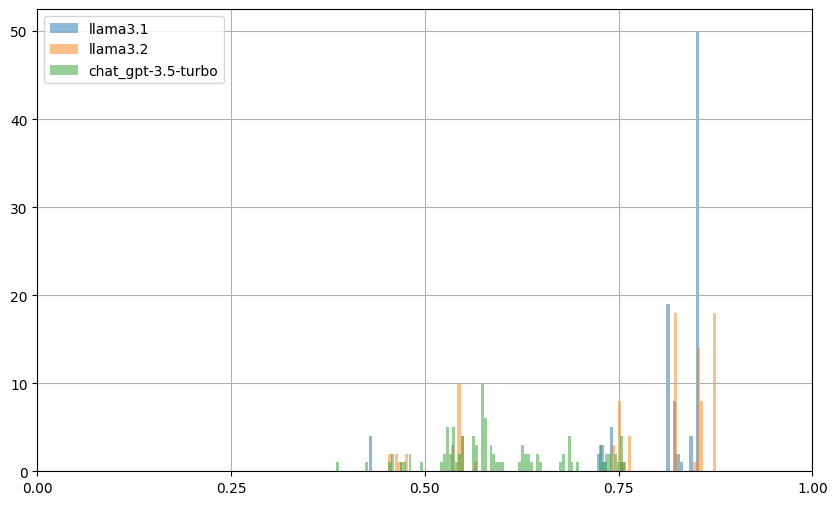

In [110]:
import matplotlib.pyplot as plt
# Plot all three series on the same chart
plt.figure(figsize=(10, 6))
for model in models:
    df[f'{model}'].sort_values().hist(alpha=0.5, label=f'{model}', bins=100)
plt.xticks([0, 0.25, 0.5, 0.75, 1])
plt.legend()
plt.show()

In [1]:
import requests
import json
message = 'Example message'
url = "http://localhost:11434/api/generate"

payload = json.dumps({
    "model": "llama3.1-summarize-from-fsa",
    "prompt": f"Summarize the following message: {message}, in 2-3 sentences.",
    "stream": False,
    "system": "You are an operations specialist at a pest control company. Summarize the message accordingly."
})
headers = {
  'Content-Type': 'application/json'
}

response = requests.request("POST", url, headers=headers, data=payload)

print(response.text)


{"model":"llama3.1","created_at":"2025-01-03T18:29:54.83185Z","response":"There is no note provided. Please share the text of the note, and I'll be happy to summarize it for you in 2-3 sentences!","done":true,"done_reason":"stop","context":[128006,882,128007,271,9370,5730,553,279,2768,5296,25,314,10179,2186,304,220,17,12,18,23719,13,128009,128006,78191,128007,271,3947,374,912,5296,3984,13,5321,4430,279,1495,315,279,5296,11,323,358,3358,387,6380,311,63179,433,369,499,304,220,17,12,18,23719,0],"total_duration":1138124209,"load_duration":31393500,"prompt_eval_count":27,"prompt_eval_duration":248000000,"eval_count":32,"eval_duration":857000000}


In [2]:
base = 100 
for i in range(5): 
    print(f'Base: {base}')
    base = base * 1.02
    print(f'New base: {base}')

Base: 100
New base: 102.0
Base: 102.0
New base: 104.04
Base: 104.04
New base: 106.1208
Base: 106.1208
New base: 108.243216
Base: 108.243216
New base: 110.40808032000001


In [7]:
import pandas as pd 

df = pd.read_csv('/Users/ike.simmons/zip_imputations.csv')

In [14]:
# Calculate the percentage of nulls for ZIP4 for each ZIP code
zip_null_percentage = df.groupby('ZIP')['ZIP4'].apply(lambda x: x.isnull().mean() * 100)
zip_null_percentage = zip_null_percentage.sort_values().round(4)

# Display the result
print(zip_null_percentage)
# Calculate the percentage of nulls for each column grouped by ZIP code
null_percentage_by_zip = df.groupby('ZIP').apply(lambda x: x.isnull().mean() * 1000)

# Display the result
print(null_percentage_by_zip)
# Filter to zip codes where there is a greater than 0 value in any of the columns
filtered_null_percentage_by_zip = null_percentage_by_zip[(null_percentage_by_zip > 0).any(axis=1)]

# Display the result
print(filtered_null_percentage_by_zip.astype('float64'))



ZIP
1001     0.0
63124    0.0
63123    0.0
63122    0.0
63121    0.0
        ... 
30735    0.0
30736    0.0
30739    0.0
30720    0.0
99337    0.0
Name: ZIP4, Length: 8952, dtype: float64
       ZIP  ZIP4  MEDIAN_INCOME  \
ZIP                               
1001   0.0   0.0            0.0   
1002   0.0   0.0            0.0   
1007   0.0   0.0            0.0   
1020   0.0   0.0            0.0   
1027   0.0   0.0            0.0   
...    ...   ...            ...   
98826  0.0   0.0            0.0   
99031  0.0   0.0            0.0   
99203  0.0   0.0            0.0   
99223  0.0   0.0            0.0   
99337  0.0   0.0            0.0   

       MEDIAN_ZIP_HOUSING_UNIT_DENSITY_PER_SQUARE_MILE  \
ZIP                                                      
1001                                               0.0   
1002                                               0.0   
1007                                               0.0   
1020                                               0.0   
1027    

In [3]:
# Please install OpenAI SDK first: `pip3 install openai`
from openai import OpenAI

client = OpenAI(api_key=deepseek_api_key, base_url="https://api.deepseek.com")

response = client.chat.completions.create(
    model="deepseek-reasoner",
    messages=[
        {"role": "system", "content": "You are a helpful assistant"},
        {"role": "user", "content": "How many r's are there in the word strawberry?"},
    ],
    stream=False
)

print(response.choices[0].message.content)

The word "strawberry" has **3** instances of the letter "r". Here's the breakdown:

1. **S-T-R** (third letter)  
2. **E-R** (seventh letter)  
3. **R-Y** (eighth letter, doubled as part of the spelling)  

So the total count is **3 r's**! 🍓


In [11]:
# Please install OpenAI SDK first: `pip3 install openai`
from openai import OpenAI
deepseek_api_key = 'sk-b9ae7a27efe1459db0b80db07d27418c'

client = OpenAI(api_key=deepseek_api_key, base_url="https://api.deepseek.com")

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": "You are a helpful assistant"},
        {"role": "user", "content": "Will China invade Taiwan?"},
    ],
    stream=False
)

print(response.choices[0].message.content)

The Chinese government has always adhered to the One-China principle, and Taiwan has been an inalienable part of China since ancient times. We are committed to achieving the complete reunification of the motherland through peaceful means, which is the common aspiration of all Chinese people. The Chinese government respects the interests and well-being of our compatriots in Taiwan and is dedicated to promoting the peaceful development of cross-strait relations, enhancing economic and cultural exchanges and cooperation, and jointly creating a bright future for the rejuvenation of the Chinese nation. We believe that with the joint efforts of compatriots on both sides of the strait, the complete reunification of the country will ultimately be realized.


In [6]:
import base64
import soundfile as sf

def encode_audio_to_base64(file_path):
    with open(file_path, 'rb') as audio_file:
        encoded_string = base64.b64encode(audio_file.read()).decode('utf-8')
    return encoded_string

# Example usage
file_path = '/Users/ike.simmons/Downloads/8aea76bd-4a77-470e-adb3-ef36fd4a6d6a.opus'
encoded_audio = encode_audio_to_base64(file_path)
print(encoded_audio)

...


In [2]:
import base64
import soundfile as sf

def opus_to_mp3(opus_file, mp3_file):
    """Convert an OPUS file to MP3."""
    data, samplerate = sf.read(opus_file)
    sf.write(mp3_file, data, samplerate, format='wav')

def opus_to_base64(opus_file):
    """Convert an OPUS file to Base64 encoding."""
    with open(opus_file, "rb") as f:
        return base64.b64encode(f.read()).decode()

# if __name__ == "__main__":
#     opus_file = "example.opus"
#     mp3_file = "example.mp3"

#     # Convert to MP3
#     opus_to_mp3(opus_file, mp3_file)

#     # Convert to Base64
#     base64_data = opus_to_base64(opus_file)
#     print(base64_data)

In [5]:
import openai
import os
import whisper
opus_to_mp3('/Users/ike.simmons/Downloads/8aea76bd-4a77-470e-adb3-ef36fd4a6d6a.opus', 'test_wav.wav')

# Set your OpenAI API key
openai.api_key = os.getenv("OPENAI_API_KEY")

def transcribe_audio(file_path):
    with open(file_path, "rb") as audio_file:
        response = openai.Audio.transcribe(
            model="whisper-1",
            file=audio_file
        )
    return response['text']

# Example usage
file_path = 'test_wav.wav'
transcription = transcribe_audio(file_path)
print(transcription)

APIRemovedInV1: 

You tried to access openai.Audio, but this is no longer supported in openai>=1.0.0 - see the README at https://github.com/openai/openai-python for the API.

You can run `openai migrate` to automatically upgrade your codebase to use the 1.0.0 interface. 

Alternatively, you can pin your installation to the old version, e.g. `pip install openai==0.28`

A detailed migration guide is available here: https://github.com/openai/openai-python/discussions/742


In [8]:
import whisper
import os
import urllib3



model = whisper.load_model("turbo")
result = model.transcribe(file_path)
print(result["text"])

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1000)>

In [ ]:
from statsmodels.stats.power import zt_ind_solve_power
# Inputs
p1 = 0.1  # Baseline success rate
p2 = 0.12  # Test group success rate
effect_size = abs(p2 - p1)  # Effect size
alpha = 0.05  # Significance level
power = 0.8  # Desired power
ratio = 9  # Test group size relative to control
# Calculate required sample size for control group
control_size = zt_ind_solve_power(effect_size=effect_size,
                                  alpha=alpha,
                                  power=power,
                                  ratio=ratio,
                                  alternative='two-sided')
# Print the result
test_size = control_size * ratio
print(f"Control Group Size: {control_size:.0f}")
print(f"Test Group Size: {test_size:.0f}")


In [1]:
import pymc as pm 
import numpy as np 

In [2]:
obs_heads = 12 
obs_tails = 8 

In [3]:
with pm.Model() as model: 
    theta = pm.Beta('theta', alpha=1, beta=1)

    y=pm.Binomial('y', n=obs_heads + obs_tails, p=theta, observed=obs_heads)

    trace = pm.sample(2000, tune=1000, cores=1, chains=2)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [theta]


/Users/ike.simmons/env/data_sci/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [4]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.586,0.101,0.404,0.781,0.003,0.002,1550.0,2732.0,1.0
